## 0. Install Required Packages ##

In [1]:
%%capture
# Installs Unsloth, Xformers (Flash Attention) and all other packages!
!pip install --no-deps --force-reinstall --no-cache-dir unsloth unsloth_zoo
!pip install --no-deps xformers "trl[peft]" bitsandbytes

In [2]:
!nvidia-smi

Fri Mar  6 13:00:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Imports & General Setups ##

In [3]:
# Unsloth

from unsloth import FastLanguageModel, unsloth_train
from unsloth.chat_templates import (
    get_chat_template,
    train_on_responses_only
)

# PyTorch
import torch

# HF
from datasets import load_dataset
from huggingface_hub import login
from trl import SFTTrainer, SFTConfig

# Google
from google.colab import userdata

# Check GPU stats
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.64 GB


In [4]:
hf_token = userdata.get('HF_TOKEN')

login(token = hf_token)

In [5]:
new_model = 'SmolLM2-Cyber'
lora_model = 'SmolLM2-Cyber_LoRA'
base_model= 'unsloth/SmolLM2-135M-Instruct'

dataset = 'madox81/mittre_severity_ds'

In [6]:
SYSTEM_PROMPT = 'You are a cybersecurity threat analysis expert. Analyze vulnerabilities and malicious behavior using structured reasoning aligned with MITRE ATT&CK and NIST frameworks. Focus exclusively on defensive analysis, detection, and mitigation. Provide clear, consistent, and technically accurate explanations.'

## 2. Loading Model & Tokenizer ##

In [7]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = base_model,
    max_seq_length = 256,
    dtype = None,
    load_in_4bit = True,
)

print("Model loaded successfully!")

==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/941 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/423 [00:00<?, ?B/s]

Model loaded successfully!


## 3. Add LoRA Adapter ##

In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 128,
    target_modules = ["q_proj", "k_proj", "v_proj",
                      "o_proj", "gate_proj", "up_proj",
                      "down_proj"],
    lora_alpha = 256,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
    use_gradient_checkpointing = "unsloth"
)

Unsloth 2026.3.3 patched 30 layers with 30 QKV layers, 30 O layers and 30 MLP layers.


## 4. Setup Chat Template & Formating Function ##

In [9]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template = 'chatml',
    map_eos_token=True,
)

Unsloth: Will map <|im_end|> to EOS = <|im_end|>.


In [10]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    # Add system prompt to each conversation if needed
    for convo in convos:
        if convo[0]["role"] != "system":
            convo.insert(0, {"role": "system", "content": SYSTEM_PROMPT})

    texts = [
        tokenizer.apply_chat_template(
            convo,
            tokenize=False,
            add_generation_prompt=False
        )
        for convo in convos
    ]
    return {"text": texts}

## 5. Load & Process Datasets ##

In [11]:
train_ds = load_dataset(dataset, split='train')
val_ds = load_dataset(dataset, split='validation')

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("=" * 50)

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/17.4k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2925 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/352 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/170 [00:00<?, ? examples/s]

Train: 2925
Val: 352


In [12]:
val_ds = val_ds.map(formatting_prompts_func, batched = True)
train_ds = train_ds.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/352 [00:00<?, ? examples/s]

Map:   0%|          | 0/2925 [00:00<?, ? examples/s]

In [13]:
train_ds['text'][0]

'<|im_start|>system\nYou are a cybersecurity threat analysis expert. Analyze vulnerabilities and malicious behavior using structured reasoning aligned with MITRE ATT&CK and NIST frameworks. Focus exclusively on defensive analysis, detection, and mitigation. Provide clear, consistent, and technically accurate explanations.<|im_end|>\n<|im_start|>user\nMap the following security event to MITRE ATT&CK tactics and techniques.\n\nInput: rule apt_lolbin { strings: $a = "certutil.exe" nocase; $b = "-urlfetch" nocase; condition: $a and $b }<|im_end|>\n<|im_start|>assistant\n{"tactics": ["Defense Evasion"], "techniques": ["InstallUtil"]}<|im_end|>\n'

## 6. Training Confgiuration ##

In [14]:
training_args = SFTConfig(

    output_dir= f'/content/drive/MyDrive/{lora_model}',

    max_length=256,

    # Training schedule
    warmup_steps=0.1,
    weight_decay=0.01,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=2,

    # Batch sizes
    per_device_eval_batch_size=16,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,

    # Precision
    bf16= False,
    fp16= True,

    # Logging & Saving
    eval_steps=25,
    save_steps=25,
    logging_steps=10,
    eval_strategy="steps",
    save_strategy="steps",
    logging_first_step=True,
    report_to="none",

    # Best model tracking
    save_total_limit=3,
    greater_is_better=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

     # Data Loading
    dataloader_num_workers = 2,
    dataloader_pin_memory=True,

    # Memory & stability
    max_grad_norm=1.0,
    gradient_checkpointing=True,
    optim = "adamw_8bit",
)

## 7. Trainer Setup ##

In [15]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    formatting_func = formatting_prompts_func,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    dataset_text_field = "text",
    max_seq_length = 256,
    args = training_args
)

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2925 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/352 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


#### *Apply Assistant Loss Only* ####

In [16]:
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

Map (num_proc=6):   0%|          | 0/2925 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/2925 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/352 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/352 [00:00<?, ? examples/s]

## 8. Training ##

In [17]:
# Check model is in 4-bit
print(f"Model dtype: {model.config.dtype}")
print(f"Quantized: {hasattr(model, 'quantization_method')}")

# Check memory usage
memory_used = torch.cuda.memory_allocated() / 1024**3
print(f"GPU Memory used: {memory_used:.2f} GB")

# Check trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,}")

Model dtype: torch.float16
Quantized: True
GPU Memory used: 0.26 GB
Trainable params: 39,075,840


In [18]:
trainer_stats = unsloth_train(trainer)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,925 | Num Epochs = 2 | Total steps = 366
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 39,075,840 of 173,591,424 (22.51% trained)


Step,Training Loss,Validation Loss
25,1.515910,0.849188
50,0.412120,0.377435
75,0.290911,0.237335
100,0.182065,0.166304
125,0.157903,0.132232
150,0.085831,0.089647
175,0.069287,0.071572
200,0.044925,0.057226
225,0.036219,0.043517
250,0.039760,0.037540


## 9. Learning Curve (Convergence) ##

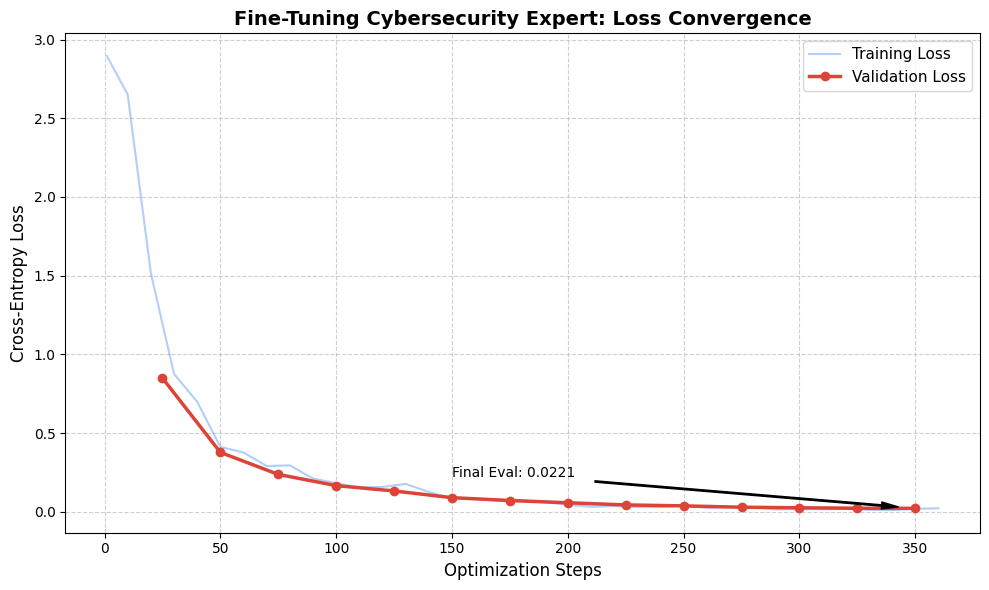

In [19]:
import matplotlib.pyplot as plt

# 1. Extract logs from the trainer state
history = trainer.state.log_history

# 2. Filter training and evaluation data separately to ensure matching dimensions
train_logs = [x for x in history if 'loss' in x]
eval_logs = [x for x in history if 'eval_loss' in x]

# 3. Extract steps and values
train_steps = [x['step'] for x in train_logs]
train_loss = [x['loss'] for x in train_logs]

eval_steps = [x['step'] for x in eval_logs]
eval_loss = [x['eval_loss'] for x in eval_logs]

# 4. Create the professional plot
plt.figure(figsize=(10, 6))

# Plot training loss as a subtle line to show the noise/trend
plt.plot(train_steps, train_loss, label='Training Loss', color='#4285F4', alpha=0.4, linewidth=1.5)

# Plot evaluation loss with markers to highlight the 100-step audit points
plt.plot(eval_steps, eval_loss, label='Validation Loss', color='#DB4437', marker='o', markersize=6, linewidth=2.5)

# 5. Add professional styling
plt.title('Fine-Tuning Cybersecurity Expert: Loss Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Optimization Steps', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=11)

# Annotate the final result
plt.annotate(f'Final Eval: {eval_loss[-1]:.4f}',
             xy=(eval_steps[-1], eval_loss[-1]),
             xytext=(eval_steps[-1]-200, eval_loss[-1]+0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('training_results_plot.png', dpi=300)
plt.show()

## 10. Publish ##

In [ ]:
model.save_pretrained(f'/content/drive/MyDrive/{lora_model}')
tokenizer.save_pretrained(f'/content/drive/MyDrive/{lora_model}')

print("✅ LoRA adapters saved locally to 'lora_adapters'")

In [ ]:
model.push_to_hub(f'madox81/{lora_model}')
tokenizer.push_to_hub(f'madox81/{lora_model}')
print(f"LoRA adapters pushed to: https://huggingface.co/madox81/{lora_model}")

In [20]:
model.push_to_hub_merged(
    f"madox81/{new_model}",
    tokenizer,
    save_method = "merged_16bit",
    token = hf_token
)

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `madox81/SmolLM2-Cyber`: 100%|██████████| 1/1 [00:02<00:00,  2.28s/it]


Successfully copied all 1 files from cache to `madox81/SmolLM2-Cyber`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2-Cyber/model.safetensors:   0%|          | 12.3kB /  269MB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:14<00:00, 14.86s/it]


Unsloth: Merge process complete. Saved to `/content/madox81/SmolLM2-Cyber`


In [ ]:
model.push_to_hub_gguf(
    f'madox81/{new_model}-GGUF',
    tokenizer,
    quantization_method = "q4_k_m",
    token = hf_token
)